In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import time
import seaborn as sns
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Dataset Loading

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

print("Train images:", train_images.shape, "Test images:", test_images.shape)

Train images: (50000, 32, 32, 3) Test images: (10000, 32, 32, 3)


In [ ]:
# Train and test dataset creation

train_df = pd.DataFrame({
    'image': list(train_images),
    'label': train_labels,
    'label_name': [CIFAR10_CLASSES[l] for l in train_labels],
    'split': 'train'
})

test_df = pd.DataFrame({
    'image': list(test_images),
    'label': test_labels,
    'label_name': [CIFAR10_CLASSES[l] for l in test_labels],
    'split': 'test'
})

cifar_df = pd.concat([train_df, test_df], ignore_index=True)
cifar_df.head()

,image,label,label_name,split
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6,frog,train
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9,truck,train
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9,truck,train
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4,deer,train
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1,automobile,train


In [4]:
print("Total rows:", len(cifar_df))
print(cifar_df['split'].value_counts())
print()
print("Class balance (train):")
print(cifar_df[cifar_df['split'] == 'train']['label_name'].value_counts())
print()
print("Single image shape/dtype:", cifar_df.iloc[0]['image'].shape, cifar_df.iloc[0]['image'].dtype)

Total rows: 60000
split
train    50000
test     10000
Name: count, dtype: int64

Class balance (train):
label_name
frog          5000
truck         5000
deer          5000
automobile    5000
bird          5000
horse         5000
ship          5000
cat           5000
dog           5000
airplane      5000
Name: count, dtype: int64

Single image shape/dtype: (32, 32, 3) uint8


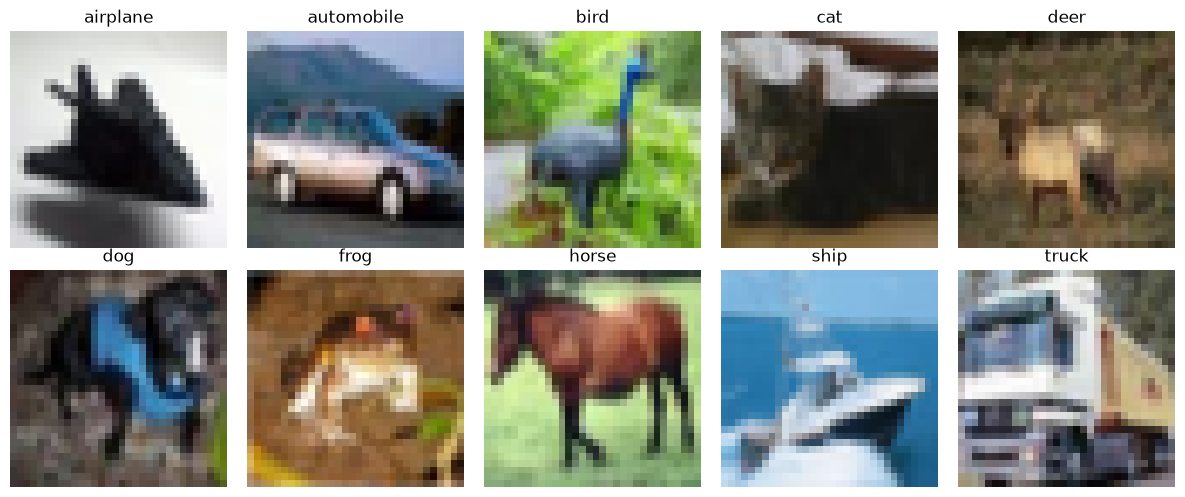

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, cls in enumerate(CIFAR10_CLASSES):
    row = cifar_df[cifar_df['label_name'] == cls].iloc[0]
    ax = axes[i // 5, i % 5]
    ax.imshow(row['image'])
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Dataset preprocessing, normalization and data format creation for different models

X_train_full = np.stack(cifar_df[cifar_df['split'] == 'train']['image'].values).astype('float32')
y_train_full = cifar_df[cifar_df['split'] == 'train']['label'].values
X_test = np.stack(cifar_df[cifar_df['split'] == 'test']['image'].values).astype('float32')
y_test = cifar_df[cifar_df['split'] == 'test']['label'].values

mean = X_train_full.mean(axis=(0, 1, 2))
std = X_train_full.std(axis=(0, 1, 2))
X_train_full = (X_train_full - mean) / std
X_test = (X_test - mean) / std

val_size = 5000
rng = np.random.RandomState(SEED)
shuffle_idx = rng.permutation(len(X_train_full))
val_idx, train_idx = shuffle_idx[:val_size], shuffle_idx[val_size:]

X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)

(45000, 3072) (5000, 3072) (10000, 3072)


In [ ]:
# Baseline MLP model

def build_mlp():
    model = keras.Sequential([
        keras.layers.Input(shape=(3072,)),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(512, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_baseline = build_mlp()
mlp_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,812,618 (14.54 MB)

 Trainable params: 3,809,034 (14.53 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

history_mlp = mlp_baseline.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.3224 - loss: 2.0035 - val_accuracy: 0.4318 - val_loss: 1.5966
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.4155 - loss: 1.6454 - val_accuracy: 0.4608 - val_loss: 1.5012
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.4584 - loss: 1.5200 - val_accuracy: 0.4802 - val_loss: 1.4367
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.4831 - loss: 1.4496 - val_accuracy: 0.4928 - val_loss: 1.4124
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.5002 - loss: 1.3979 - val_accuracy: 0.5056 - val_loss: 1.3894
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.5147 - loss: 1.3573 - val_accuracy: 0.5200 - val_loss: 1.3446
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.5271 - loss: 1.3203 - val_accuracy: 0.5206 - val_loss: 1.3395
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.5421 - loss: 1.2855 - 

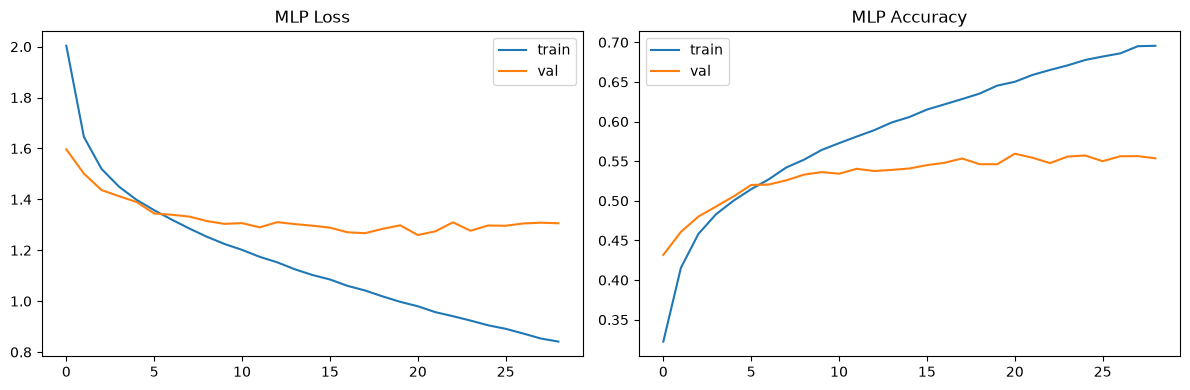

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_mlp.history['loss'], label='train')
axes[0].plot(history_mlp.history['val_loss'], label='val')
axes[0].set_title('MLP Loss')
axes[0].legend()

axes[1].plot(history_mlp.history['accuracy'], label='train')
axes[1].plot(history_mlp.history['val_accuracy'], label='val')
axes[1].set_title('MLP Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Central results storage

results_store = []

def evaluate_and_log(model_name, model, X_eval, y_eval, extra_info=None):
    start = time.time()
    y_prob = model.predict(X_eval, verbose=0)
    inference_time = time.time() - start
    y_pred = np.argmax(y_prob, axis=1)

    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'macro_f1': f1_score(y_eval, y_pred, average='macro'),
        'precision_macro': precision_score(y_eval, y_pred, average='macro'),
        'recall_macro': recall_score(y_eval, y_pred, average='macro'),
        'n_params': model.count_params(),
        'inference_time_sec': inference_time,
    }
    if extra_info:
        metrics.update(extra_info)

    results_store.append(metrics)
    print(metrics)
    return metrics, confusion_matrix(y_eval, y_pred)

mlp_metrics, mlp_cm = evaluate_and_log('MLP_baseline_raw_pixels', mlp_baseline, X_test_flat, y_test)

{'model_name': 'MLP_baseline_raw_pixels', 'accuracy': 0.5733, 'macro_f1': 0.5728999776020121, 'precision_macro': 0.5748830914129429, 'recall_macro': 0.5732999999999999, 'n_params': 3812618, 'inference_time_sec': 2.8063724040985107}


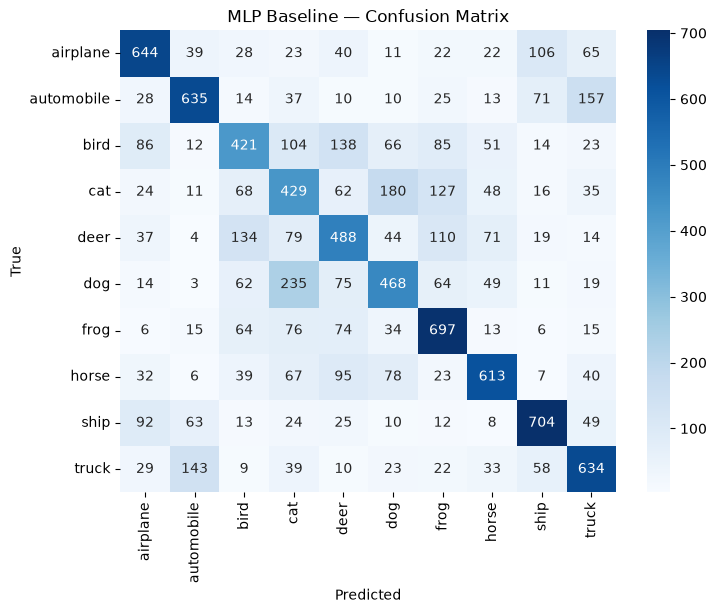

In [ ]:
# Confusion matrix for the baseline

plt.figure(figsize=(8, 6))
sns.heatmap(mlp_cm, annot=True, fmt='d', xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP Baseline — Confusion Matrix')
plt.show()

In [ ]:
# Autoencoder model

LATENT_DIM = 128

# --- Encoder ---
ae_encoder_input = keras.Input(shape=(32, 32, 3))
x = keras.layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(ae_encoder_input)
x = keras.layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Flatten()(x)
ae_bottleneck = keras.layers.Dense(LATENT_DIM, activation='linear', name='bottleneck')(x)

ae_encoder = keras.Model(ae_encoder_input, ae_bottleneck, name='ae_encoder')

# --- Decoder ---
ae_decoder_input = keras.Input(shape=(LATENT_DIM,))
x = keras.layers.Dense(4 * 4 * 128, activation='relu')(ae_decoder_input)
x = keras.layers.Reshape((4, 4, 128))(x)
x = keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
ae_decoder_output = keras.layers.Conv2D(3, 3, padding='same', activation='linear')(x)

ae_decoder = keras.Model(ae_decoder_input, ae_decoder_output, name='ae_decoder')

# --- Full autoencoder ---
autoencoder = keras.Model(ae_encoder_input, ae_decoder(ae_encoder(ae_encoder_input)), name='autoencoder')
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ ae_encoder (Functional)              │ (None, 128)                 │         355,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ ae_decoder (Functional)              │ (None, 32, 32, 3)           │         504,899 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 860,419 (3.28 MB)

 Trainable params: 860,419 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
ae_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

history_ae = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=40,
    batch_size=128,
    callbacks=[ae_early_stop],
    verbose=1
)

Epoch 1/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 110ms/step - loss: 0.3389 - val_loss: 0.1760
Epoch 2/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - loss: 0.1510 - val_loss: 0.1333
Epoch 3/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - loss: 0.1219 - val_loss: 0.1089
Epoch 4/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - loss: 0.1030 - val_loss: 0.0959
Epoch 5/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - loss: 0.0926 - val_loss: 0.0896
Epoch 6/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - loss: 0.0871 - val_loss: 0.0859
Epoch 7/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - loss: 0.0832 - val_loss: 0.0838
Epoch 8/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - loss: 0.0809 - val_loss: 0.0802
Epoch 9/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - loss: 0.0792 - val_loss: 0.0795
Epoch 10/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 45s 115ms/step - loss: 0.0778 - val_loss: 0.0782
Epoch 11/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - loss: 0.0768 - val_loss: 0.0773
Epoch 12/40
352/352

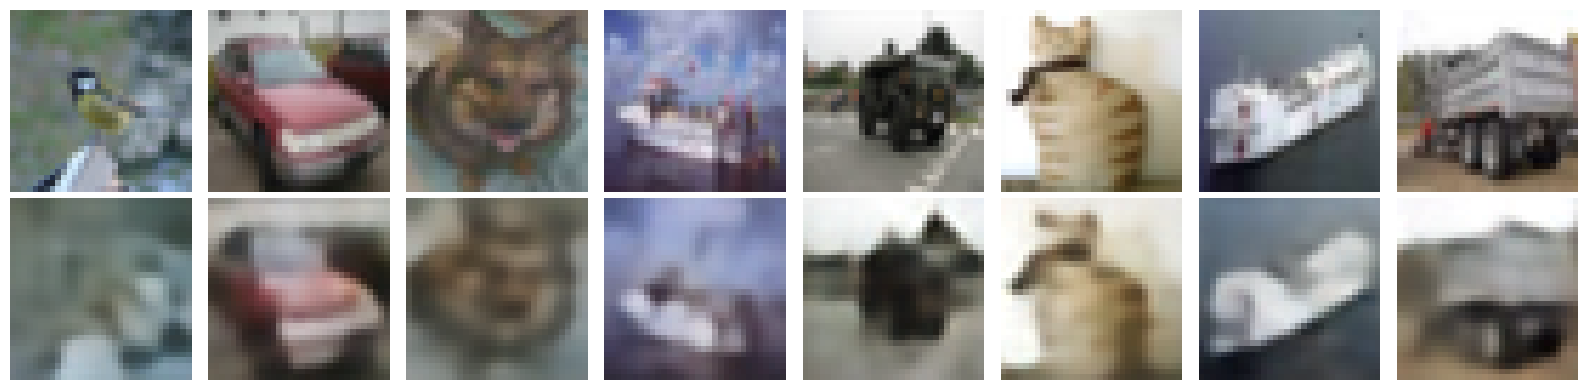

In [ ]:
# Visualization of original vs reconstructed images

def unnormalize(img):
    return np.clip(img * std + mean, 0, 255).astype('uint8')

n_show = 8
sample_idx = np.random.RandomState(SEED).choice(len(X_test), n_show, replace=False)
sample_imgs = X_test[sample_idx]
recon_imgs = autoencoder.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    axes[0, i].imshow(unnormalize(sample_imgs[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(unnormalize(recon_imgs[i]))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')
plt.tight_layout()
plt.show()

In [ ]:
# Extraction of compressed AE latent features for classification model later on

X_train_ae_latent = ae_encoder.predict(X_train, verbose=0)
X_val_ae_latent = ae_encoder.predict(X_val, verbose=0)
X_test_ae_latent = ae_encoder.predict(X_test, verbose=0)

print(X_train_ae_latent.shape, X_val_ae_latent.shape, X_test_ae_latent.shape)

(45000, 128) (5000, 128) (10000, 128)


In [ ]:
# Generalized version of the MLP builder (parameterized input size)

def build_mlp(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(512, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# MLP on AE latent space

mlp_ae_latent = build_mlp(input_dim=LATENT_DIM)

history_mlp_ae = mlp_ae_latent.fit(
    X_train_ae_latent, y_train,
    validation_data=(X_val_ae_latent, y_val),
    epochs=60,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
)

mlp_ae_metrics, mlp_ae_cm = evaluate_and_log(
    'MLP_on_AE_latent', mlp_ae_latent, X_test_ae_latent, y_test,
    extra_info={'latent_dim': LATENT_DIM}
)

Epoch 1/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3494 - loss: 1.9222 - val_accuracy: 0.4560 - val_loss: 1.5187
Epoch 2/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4459 - loss: 1.5525 - val_accuracy: 0.4918 - val_loss: 1.4146
Epoch 3/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.4867 - loss: 1.4336 - val_accuracy: 0.5100 - val_loss: 1.3549
Epoch 4/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.5136 - loss: 1.3564 - val_accuracy: 0.5274 - val_loss: 1.3154
Epoch 5/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.5356 - loss: 1.2977 - val_accuracy: 0.5330 - val_loss: 1.2917
Epoch 6/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5520 - loss: 1.2483 - val_accuracy: 0.5472 - val_loss: 1.2743
Epoch 7/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.5678 - loss: 1.2036 - val_accuracy: 0.5486 - val_loss: 1.2621
Epoch 8/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5824 - loss: 1.1628 - val

In [ ]:
# Variational Autoencoder

class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- VAE Encoder ---
vae_encoder_input = keras.Input(shape=(32, 32, 3))
x = keras.layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(vae_encoder_input)
x = keras.layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Flatten()(x)

z_mean = keras.layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = keras.layers.Dense(LATENT_DIM, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])

vae_encoder = keras.Model(vae_encoder_input, [z_mean, z_log_var, z], name='vae_encoder')

# --- VAE Decoder (same architecture as AE decoder) ---
vae_decoder_input = keras.Input(shape=(LATENT_DIM,))
x = keras.layers.Dense(4 * 4 * 128, activation='relu')(vae_decoder_input)
x = keras.layers.Reshape((4, 4, 128))(x)
x = keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
vae_decoder_output = keras.layers.Conv2D(3, 3, padding='same', activation='linear')(x)

vae_decoder = keras.Model(vae_decoder_input, vae_decoder_output, name='vae_decoder')

In [ ]:
# Custom loss function, train and test steps

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.0005, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3]))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        total_loss, recon_loss, kl_loss = self._compute_losses(x)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

vae = VAE(vae_encoder, vae_decoder, beta=0.0005)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

In [19]:
history_vae = vae.fit(
    X_train,
    validation_data=(X_val,),
    epochs=40,
    batch_size=128,
    verbose=1
)

Epoch 1/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - kl_loss: 840.3354 - loss: 984.0571 - recon_loss: 983.6363 - val_kl_loss: 975.1548 - val_loss: 527.2921 - val_recon_loss: 526.8043
Epoch 2/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - kl_loss: 977.6617 - loss: 465.1375 - recon_loss: 464.6485 - val_kl_loss: 1008.2721 - val_loss: 407.8074 - val_recon_loss: 407.3033
Epoch 3/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - kl_loss: 983.0520 - loss: 370.7843 - recon_loss: 370.2927 - val_kl_loss: 998.1927 - val_loss: 332.5097 - val_recon_loss: 332.0106
Epoch 4/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - kl_loss: 965.6970 - loss: 312.4110 - recon_loss: 311.9282 - val_kl_loss: 961.7750 - val_loss: 295.1732 - val_recon_loss: 294.6923
Epoch 5/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - kl_loss: 936.3271 - loss: 283.2117 - recon_loss: 282.7434 - val_kl_loss: 927.2034 - val_loss: 275.0227 - val_recon_loss: 274.5590
Epoch 6/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - kl_loss: 

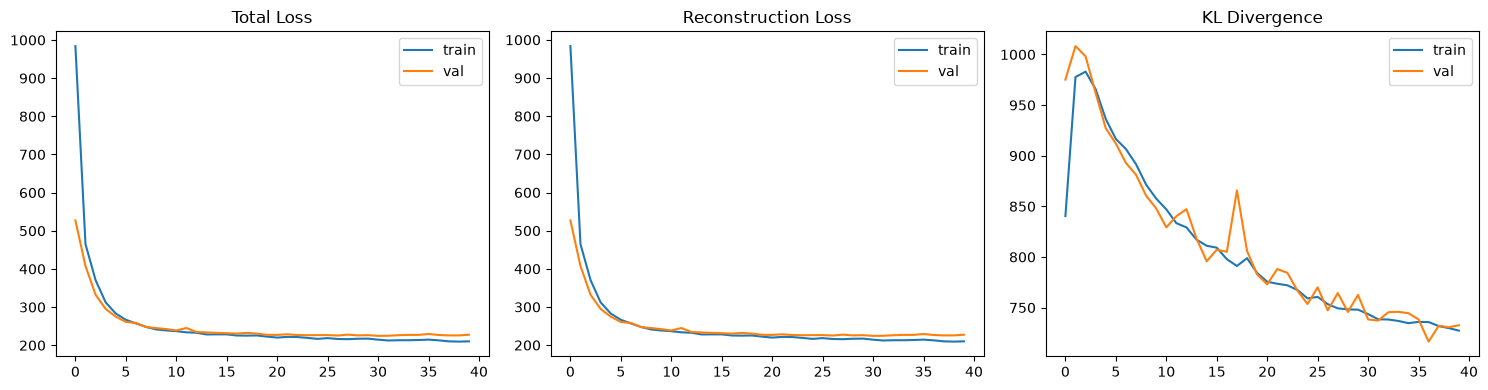

In [ ]:
# VAE loss curves

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history_vae.history['loss'], label='train')
axes[0].plot(history_vae.history['val_loss'], label='val')
axes[0].set_title('Total Loss')
axes[0].legend()

axes[1].plot(history_vae.history['recon_loss'], label='train')
axes[1].plot(history_vae.history['val_recon_loss'], label='val')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()

axes[2].plot(history_vae.history['kl_loss'], label='train')
axes[2].plot(history_vae.history['val_kl_loss'], label='val')
axes[2].set_title('KL Divergence')
axes[2].legend()
plt.tight_layout()
plt.show()

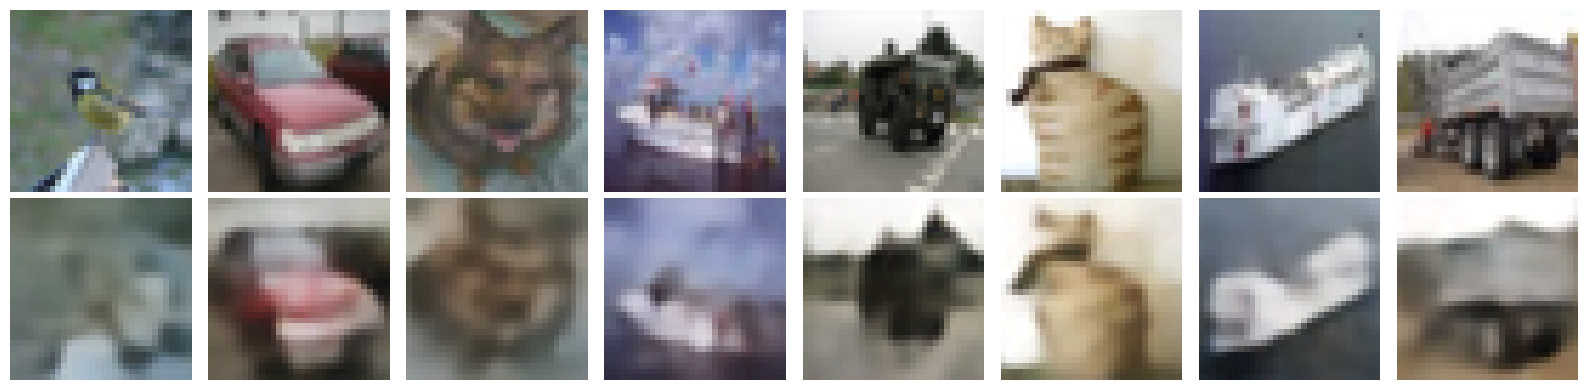

In [ ]:
# VAE reconstructions (using the sampled z, not just z_mean, to show generative behavior)

_, _, sample_z = vae_encoder.predict(sample_imgs, verbose=0)
vae_recon_imgs = vae_decoder.predict(sample_z, verbose=0)

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    axes[0, i].imshow(unnormalize(sample_imgs[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(unnormalize(vae_recon_imgs[i]))
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

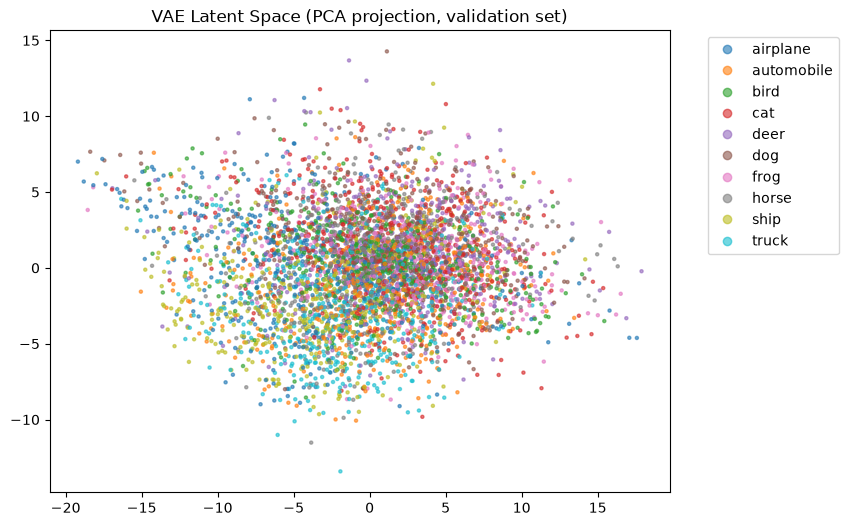

In [ ]:
# 2D latent space visualization via PCA on z_mean, colored by class

z_mean_val, _, _ = vae_encoder.predict(X_val, verbose=0)
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_mean_val)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_val, cmap='tab10', s=5, alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=CIFAR10_CLASSES, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('VAE Latent Space (PCA projection, validation set)')
plt.show()

In [ ]:
# Extraction of VAE latent features for classification model later on

X_train_vae_latent, _, _ = vae_encoder.predict(X_train, verbose=0)
X_val_vae_latent, _, _ = vae_encoder.predict(X_val, verbose=0)
X_test_vae_latent, _, _ = vae_encoder.predict(X_test, verbose=0)

print(X_train_vae_latent.shape, X_val_vae_latent.shape, X_test_vae_latent.shape)

(45000, 128) (5000, 128) (10000, 128)


In [ ]:
# MLP on VAE latent space

mlp_vae_latent = build_mlp(input_dim=LATENT_DIM)

history_mlp_vae = mlp_vae_latent.fit(
    X_train_vae_latent, y_train,
    validation_data=(X_val_vae_latent, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
)

mlp_vae_metrics, mlp_vae_cm = evaluate_and_log(
    'MLP_on_VAE_latent', mlp_vae_latent, X_test_vae_latent, y_test,
    extra_info={'latent_dim': LATENT_DIM}
)


Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.3534 - loss: 1.9277 - val_accuracy: 0.4498 - val_loss: 1.5252
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.4504 - loss: 1.5485 - val_accuracy: 0.4888 - val_loss: 1.4120
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.4875 - loss: 1.4311 - val_accuracy: 0.5072 - val_loss: 1.3648
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5166 - loss: 1.3491 - val_accuracy: 0.5182 - val_loss: 1.3257
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5386 - loss: 1.2901 - val_accuracy: 0.5296 - val_loss: 1.3035
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.5541 - loss: 1.2391 - val_accuracy: 0.5434 - val_loss: 1.2722
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5732 - loss: 1.1922 - val_accuracy: 0.5426 - val_loss: 1.2698
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5867 - loss: 1.1502 - 

In [ ]:
# Quick comparison so far: raw pixels vs AE-compressed vs VAE-compressed

pd.DataFrame(results_store)[['model_name', 'accuracy', 'macro_f1', 'n_params']]

,model_name,accuracy,macro_f1,n_params
0,MLP_baseline_raw_pixels,0.5733,0.572900,3812618
1,MLP_on_AE_latent,0.5722,0.569160,797962
2,MLP_on_VAE_latent,0.5631,0.559285,797962


In [26]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

In [ ]:
# Shallow CNN model

def build_cnn_simple():
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)
    x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='cnn_simple')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_simple = build_cnn_simple()
cnn_simple.summary()

Model: "cnn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Deep CNN model with optimized blocks to train faster

def residual_block(x, filters):
    shortcut = x
    y = keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    y = keras.layers.BatchNormalization()(y)
    y = keras.layers.ReLU()(y)
    y = keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(y)
    y = keras.layers.BatchNormalization()(y)
    if shortcut.shape[-1] != filters:
        shortcut = keras.layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
    out = keras.layers.Add()([shortcut, y])
    return keras.layers.ReLU()(out)

def optimized_residual_block(x, filters):
    shortcut = x
    y = keras.layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    y = keras.layers.BatchNormalization()(y)
    y = keras.layers.ReLU()(y)
    y = keras.layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(y)
    y = keras.layers.BatchNormalization()(y)
    if shortcut.shape[-1] != filters:
        shortcut = keras.layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)
    out = keras.layers.Add()([shortcut, y])
    return keras.layers.ReLU()(out)

def build_cnn_deep_residual():
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)
    x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = residual_block(x, 32)
    x = keras.layers.MaxPooling2D()(x)
    x = optimized_residual_block(x, 64)
    x = keras.layers.MaxPooling2D()(x)
    x = optimized_residual_block(x, 128)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='cnn_deep_residual')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_deep_residual = build_cnn_deep_residual()
cnn_deep_residual.summary()

Model: "cnn_deep_residual"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)    │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation             │ (None, 32, 32, 3)         │               0 │ input_layer_9[0][0]        │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 32, 32, 32)        │             896 │ data_augmentation[1][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 32, 32, 32)        │           9,216 │ conv2d_10[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_9         │ (None, 32, 32, 32)        │             128 │ conv2d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 32, 32, 32)        │               0 │ batch_normalization_9[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 32, 32, 32)        │           9,216 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 32, 32, 32)        │             128 │ conv2d_12[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 32, 32, 32)        │               0 │ conv2d_10[0][0],           │
│                               │                           │                 │ batch_normalization_10[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 32, 32, 32)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 16, 16, 32)        │               0 │ re_lu_1[0][0]              │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv2d              │ (None, 16, 16, 64)        │           2,336 │ max_pooling2d_2[0][0]      │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_11        │ (None, 16, 16, 64)        │             256 │ separable_conv2d[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 16, 16, 64)        │               

 Total params: 593,578 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Wide CNN model

def build_cnn_wide_gap():
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)
    x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.SeparableConv2D(128, 3, padding='same', activation='relu')(x)
    x = keras.layers.SeparableConv2D(128, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.SeparableConv2D(256, 3, padding='same', activation='relu')(x)
    x = keras.layers.SeparableConv2D(256, 3, padding='same', activation='relu')(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='cnn_wide_gap')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_wide_gap = build_cnn_wide_gap()
cnn_wide_gap.summary()

Model: "cnn_wide_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ separable_conv2d_4 (SeparableConv2D) │ (None, 16, 16, 128)         │           8,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ separable_conv2d_5 (SeparableConv2D) │ (None, 16, 16, 128)         │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ separable_conv2d_6 (SeparableConv2D) │ (None, 8, 8, 256)           │          34,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ separable_conv2d_7 (SeparableConv2D) │ (None, 8, 8, 256)           │          68,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 170,122 (664.54 KB)

 Trainable params: 170,122 (664.54 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
cnn_models = {
    'CNN_shallow': cnn_simple,
    'CNN_deep_residual': cnn_deep_residual,
    'CNN_wide_gap': cnn_wide_gap
}

cnn_histories = {}

for name, model in cnn_models.items():
    print(f"\n===== Training {name} =====")
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1
    )
    cnn_histories[name] = history
    print(f"\n===== Completed Training {name} =====\n")


===== Training CNN_shallow =====
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.4309 - loss: 1.5856 - val_accuracy: 0.5514 - val_loss: 1.2454
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.5532 - loss: 1.2528 - val_accuracy: 0.5928 - val_loss: 1.1418
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.5995 - loss: 1.1345 - val_accuracy: 0.6428 - val_loss: 1.0456
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.6232 - loss: 1.0702 - val_accuracy: 0.6566 - val_loss: 0.9954
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6445 - loss: 1.0139 - val_accuracy: 0.6896 - val_loss: 0.8797
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.6588 - loss: 0.9726 - val_accuracy: 0.7052 - val_loss: 0.8613
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.6724 - loss: 0.9372 - val_accuracy: 0.7108 - val_loss: 0.8444
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - 

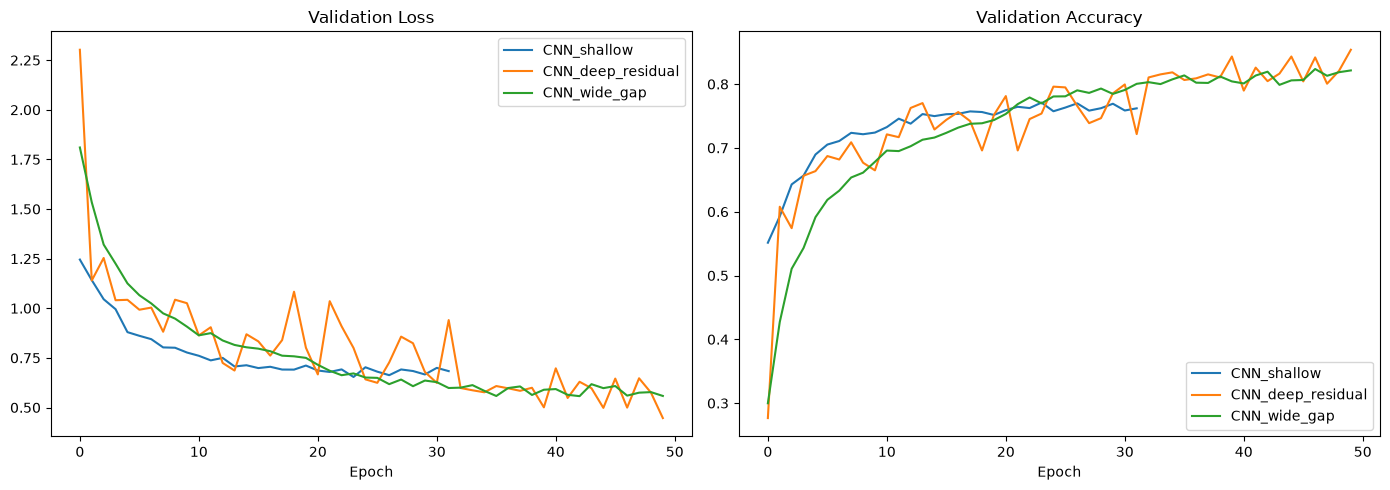

In [ ]:
# CNN models training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, history in cnn_histories.items():
    axes[0].plot(history.history['val_loss'], label=name)
    axes[1].plot(history.history['val_accuracy'], label=name)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [32]:
cnn_confusion_matrices = {}

for name, model in cnn_models.items():
    metrics, cm = evaluate_and_log(
        name, model, X_test, y_test,
        extra_info={'architecture': name}
    )
    cnn_confusion_matrices[name] = cm

{'model_name': 'CNN_shallow', 'accuracy': 0.771, 'macro_f1': 0.7683283964868026, 'precision_macro': 0.769513080215624, 'recall_macro': 0.771, 'n_params': 545098, 'inference_time_sec': 4.596531629562378, 'architecture': 'CNN_shallow'}
{'model_name': 'CNN_deep_residual', 'accuracy': 0.8417, 'macro_f1': 0.8414359267573213, 'precision_macro': 0.8475655903200938, 'recall_macro': 0.8417, 'n_params': 593578, 'inference_time_sec': 20.774674892425537, 'architecture': 'CNN_deep_residual'}
{'model_name': 'CNN_wide_gap', 'accuracy': 0.8107, 'macro_f1': 0.8072615945455887, 'precision_macro': 0.8142070596992683, 'recall_macro': 0.8107, 'n_params': 170122, 'inference_time_sec': 20.899694442749023, 'architecture': 'CNN_wide_gap'}


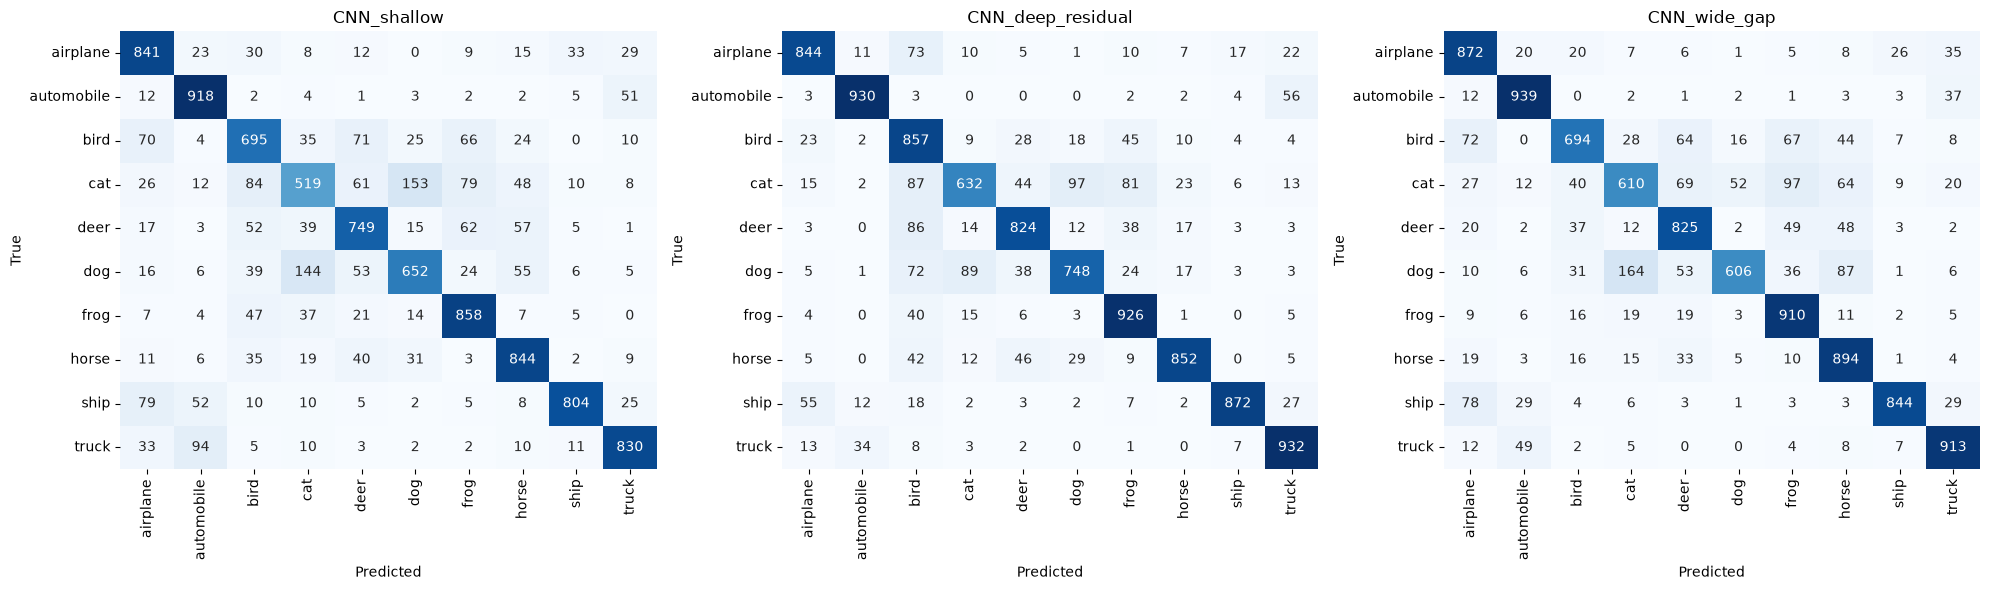

In [ ]:
# Side-by-side CNN confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, cm) in zip(axes, cnn_confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

In [ ]:
# Updated comparison across everything so far

pd.DataFrame(results_store)[['model_name', 'accuracy', 'macro_f1', 'n_params', 'inference_time_sec']]

,model_name,accuracy,macro_f1,n_params,inference_time_sec
0,MLP_baseline_raw_pixels,0.5733,0.572900,3812618,2.806372
1,MLP_on_AE_latent,0.5722,0.569160,797962,2.698686
2,MLP_on_VAE_latent,0.5631,0.559285,797962,2.719216
3,CNN_shallow,0.7710,0.768328,545098,4.596532
4,CNN_deep_residual,0.8417,0.841436,593578,20.774675
5,CNN_wide_gap,0.8107,0.807262,170122,20.899694


In [ ]:
NUM_CLASSES = 10
LATENT_DIM_GAN = 100

X_train_gan = (train_images[train_idx].astype('float32') - 127.5) / 127.5   # [-1, 1]
y_train_gan = y_train_full[train_idx]

BUFFER_SIZE = X_train_gan.shape[0]
BATCH_SIZE = 128

gan_dataset = tf.data.Dataset.from_tensor_slices((X_train_gan, y_train_gan))
gan_dataset = gan_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

In [ ]:
# CGAN generator model

def build_generator():
    noise_input = keras.Input(shape=(LATENT_DIM_GAN,))
    label_input = keras.Input(shape=(1,), dtype='int32')

    label_embed = keras.layers.Embedding(NUM_CLASSES, LATENT_DIM_GAN)(label_input)
    label_embed = keras.layers.Flatten()(label_embed)

    x = keras.layers.Multiply()([noise_input, label_embed])

    x = keras.layers.Dense(4 * 4 * 256, use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(0.2)(x)
    x = keras.layers.Reshape((4, 4, 256))(x)

    x = keras.layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(0.2)(x)

    x = keras.layers.Conv2DTranspose(64, 4, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(0.2)(x)

    x = keras.layers.Conv2DTranspose(3, 4, strides=2, padding='same', use_bias=False, activation='tanh')(x)

    model = keras.Model([noise_input, label_input], x, name='generator')
    return model

generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)   │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 1, 100)            │           1,000 │ input_layer_12[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_11 (InputLayer)   │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_4 (Flatten)           │ (None, 100)               │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 100)               │               0 │ input_layer_11[0][0],      │
│                               │                           │                 │ flatten_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_19 (Dense)              │ (None, 4096)              │         409,600 │ multiply[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_18        │ (None, 4096)              │          16,384 │ dense_19[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)       │ (None, 4096)              │               0 │ batch_normalization_18[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_2 (Reshape)           │ (None, 4, 4, 256)         │               0 │ leaky_re_lu[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_6            │ (None, 8, 8, 128)         │         524,288 │ reshape_2[0][0]            │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_19        │ (None, 8, 8, 128)         │             512 │ conv2d_transpose_6[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 8, 8, 128)         │               0 │ batch_normalization_19[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_7            │ (None, 16, 16, 64)        │         131,072 │ leaky_re_lu_1[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_20        │ (None, 16, 16, 64)        │             256 │ conv2d_transpose_7[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,086,184 (4.14 MB)

 Trainable params: 1,077,608 (4.11 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [ ]:
# CGAN discriminator model

def build_discriminator():
    image_input = keras.Input(shape=(32, 32, 3))
    label_input = keras.Input(shape=(1,), dtype='int32')

    label_embed = keras.layers.Embedding(NUM_CLASSES, 32 * 32)(label_input)
    label_embed = keras.layers.Reshape((32, 32, 1))(label_embed)

    x = keras.layers.Concatenate()([image_input, label_embed])

    x = keras.layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x = keras.layers.LeakyReLU(0.2)(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(0.2)(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(0.2)(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model([image_input, label_input], x, name='discriminator')
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)   │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 1, 1024)           │          10,240 │ input_layer_14[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_13 (InputLayer)   │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_3 (Reshape)           │ (None, 32, 32, 1)         │               0 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 32, 32, 4)         │               0 │ input_layer_13[0][0],      │
│                               │                           │                 │ reshape_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_17 (Conv2D)            │ (None, 16, 16, 64)        │           4,160 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 16, 16, 64)        │               0 │ conv2d_17[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_12 (Dropout)          │ (None, 16, 16, 64)        │               0 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_18 (Conv2D)            │ (None, 8, 8, 128)         │         131,200 │ dropout_12[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_21        │ (None, 8, 8, 128)         │             512 │ conv2d_18[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU)     │ (None, 8, 8, 128)         │               0 │ batch_normalization_21[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 8, 8, 128)         │               0 │ leaky_re_lu_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_19 (Conv2D)            │ (None, 4, 4, 256)         │         524,544 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_22        │ (None, 4, 4, 256)         │           1,024 │ conv2d_19[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU)     │ (None, 4, 4, 256)         │               0 │ batch_normalization_22[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_14 (Dropout)          │ (None, 4, 4, 256)         │               

 Total params: 675,777 (2.58 MB)

 Trainable params: 675,009 (2.57 MB)

 Non-trainable params: 768 (3.00 KB)

In [38]:
cross_entropy = keras.losses.BinaryCrossentropy()

gen_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)

# One-sided label smoothing on real labels helps discriminator stability
REAL_LABEL_SMOOTH = 0.9

@tf.function
def train_step(real_images, real_labels):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM_GAN])
    fake_labels = tf.random.uniform([batch_size, 1], 0, NUM_CLASSES, dtype=tf.int32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator([noise, fake_labels], training=True)

        real_output = discriminator([real_images, real_labels], training=True)
        fake_output = discriminator([fake_images, fake_labels], training=True)

        disc_loss = (
            cross_entropy(tf.ones_like(real_output) * REAL_LABEL_SMOOTH, real_output) +
            cross_entropy(tf.zeros_like(fake_output), fake_output)
        )
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return gen_loss, disc_loss

Epoch 1/50 — gen_loss: 2.5716, disc_loss: 0.6908


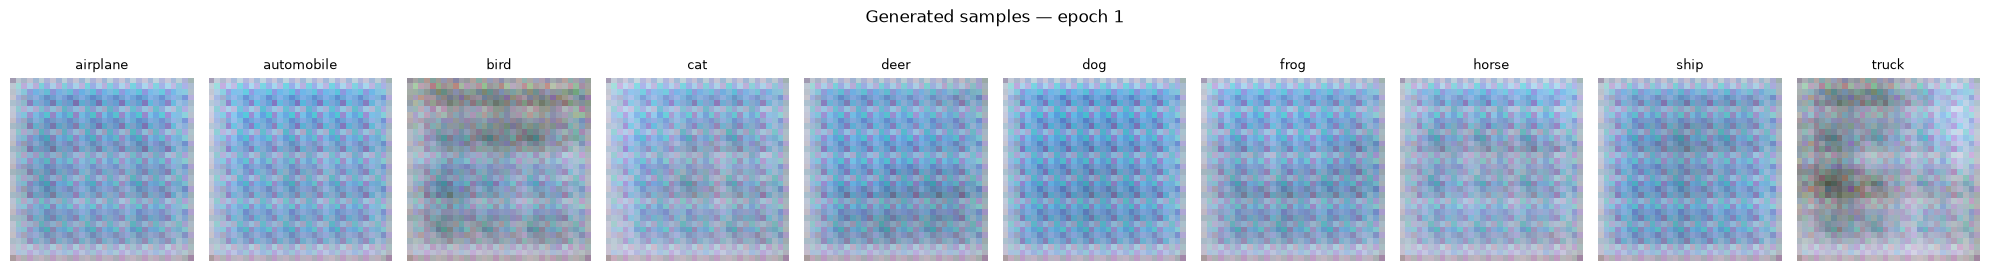

Epoch 2/50 — gen_loss: 2.2740, disc_loss: 0.8138
Epoch 3/50 — gen_loss: 2.0695, disc_loss: 0.8328
Epoch 4/50 — gen_loss: 2.0120, disc_loss: 0.8401
Epoch 5/50 — gen_loss: 1.9355, disc_loss: 0.8740
Epoch 6/50 — gen_loss: 1.8860, disc_loss: 0.8995
Epoch 7/50 — gen_loss: 1.8324, disc_loss: 0.9361
Epoch 8/50 — gen_loss: 1.7062, disc_loss: 0.9783
Epoch 9/50 — gen_loss: 1.6951, disc_loss: 0.9876
Epoch 10/50 — gen_loss: 1.6380, disc_loss: 1.0068


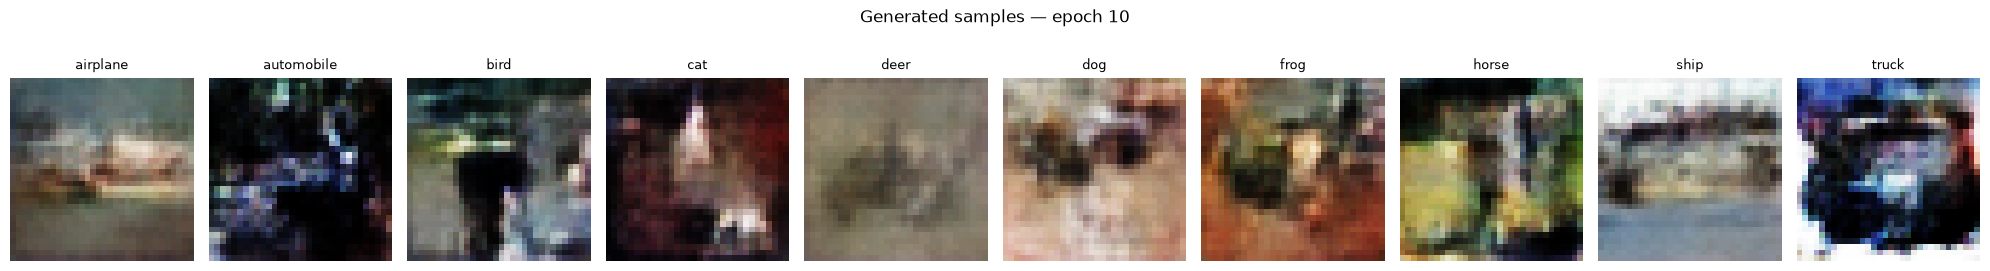

Epoch 11/50 — gen_loss: 1.6374, disc_loss: 0.9936
Epoch 12/50 — gen_loss: 1.6488, disc_loss: 0.9857
Epoch 13/50 — gen_loss: 1.6629, disc_loss: 0.9782
Epoch 14/50 — gen_loss: 1.6962, disc_loss: 0.9744
Epoch 15/50 — gen_loss: 1.6974, disc_loss: 0.9748
Epoch 16/50 — gen_loss: 1.6991, disc_loss: 0.9712
Epoch 17/50 — gen_loss: 1.7124, disc_loss: 0.9702
Epoch 18/50 — gen_loss: 1.6848, disc_loss: 0.9873
Epoch 19/50 — gen_loss: 1.6934, disc_loss: 0.9877
Epoch 20/50 — gen_loss: 1.6856, disc_loss: 0.9842


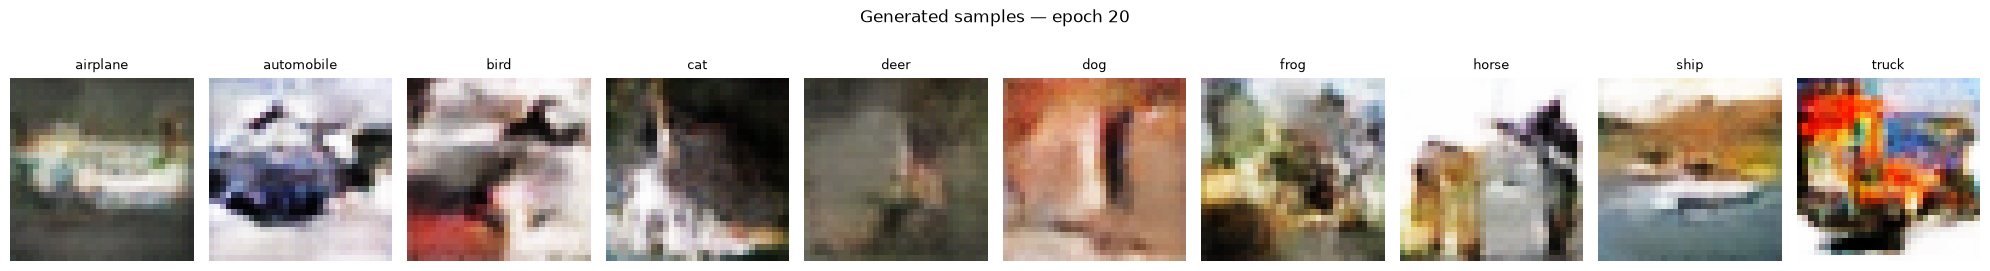

Epoch 21/50 — gen_loss: 1.6820, disc_loss: 0.9789
Epoch 22/50 — gen_loss: 1.7104, disc_loss: 0.9884
Epoch 23/50 — gen_loss: 1.7333, disc_loss: 0.9598
Epoch 24/50 — gen_loss: 1.7134, disc_loss: 0.9635
Epoch 25/50 — gen_loss: 1.7531, disc_loss: 0.9673
Epoch 26/50 — gen_loss: 1.6990, disc_loss: 0.9840
Epoch 27/50 — gen_loss: 1.7685, disc_loss: 0.9557
Epoch 28/50 — gen_loss: 1.7675, disc_loss: 0.9537
Epoch 29/50 — gen_loss: 1.8073, disc_loss: 0.9539
Epoch 30/50 — gen_loss: 1.8097, disc_loss: 0.9402


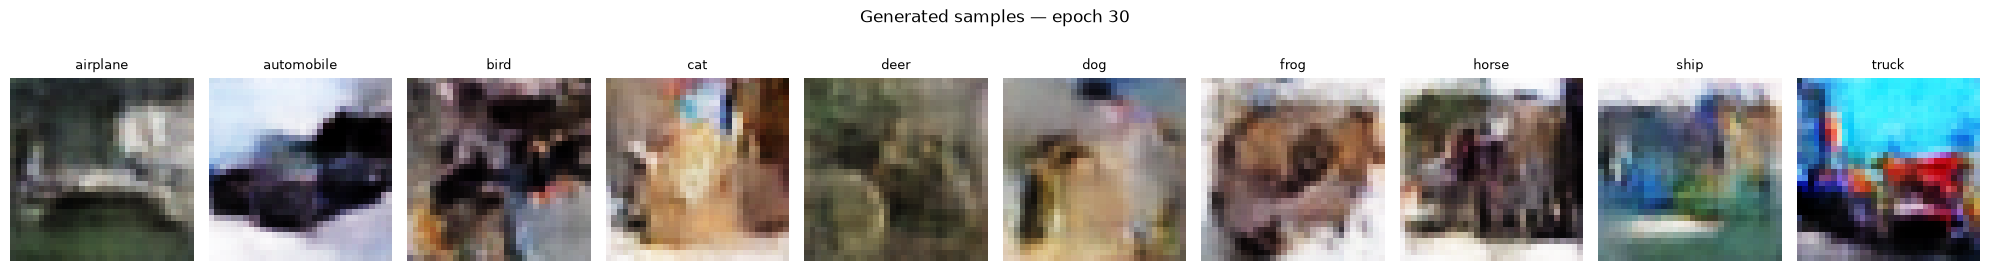

Epoch 31/50 — gen_loss: 1.7608, disc_loss: 0.9781
Epoch 32/50 — gen_loss: 1.7948, disc_loss: 0.9403
Epoch 33/50 — gen_loss: 1.8089, disc_loss: 0.9518
Epoch 34/50 — gen_loss: 1.7914, disc_loss: 0.9642
Epoch 35/50 — gen_loss: 1.8147, disc_loss: 0.9441
Epoch 36/50 — gen_loss: 1.7939, disc_loss: 0.9656
Epoch 37/50 — gen_loss: 1.8111, disc_loss: 0.9478
Epoch 38/50 — gen_loss: 1.8177, disc_loss: 0.9472
Epoch 39/50 — gen_loss: 1.7888, disc_loss: 0.9684
Epoch 40/50 — gen_loss: 1.7939, disc_loss: 0.9616


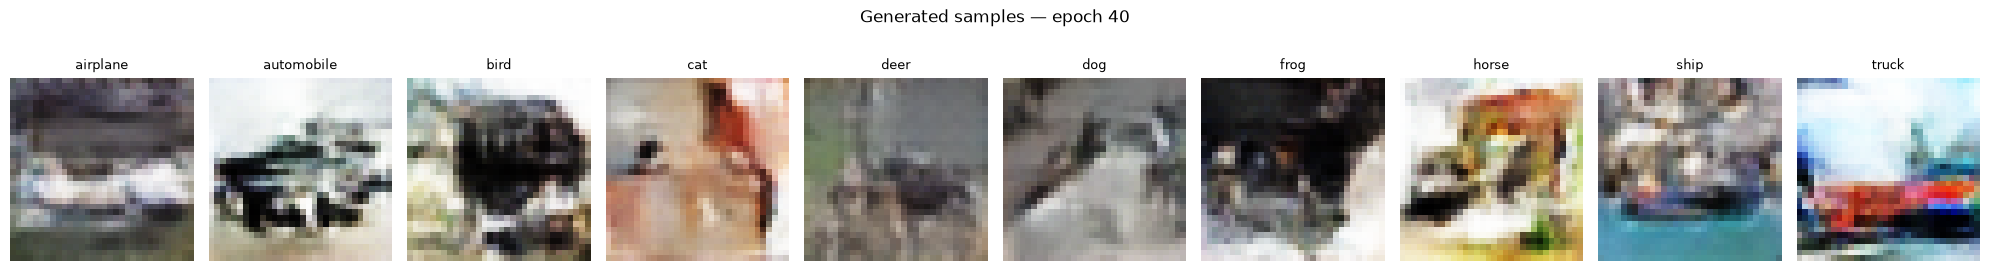

Epoch 41/50 — gen_loss: 1.8334, disc_loss: 0.9526
Epoch 42/50 — gen_loss: 1.8164, disc_loss: 0.9371
Epoch 43/50 — gen_loss: 1.8157, disc_loss: 0.9502
Epoch 44/50 — gen_loss: 1.8234, disc_loss: 0.9562
Epoch 45/50 — gen_loss: 1.8166, disc_loss: 0.9530
Epoch 46/50 — gen_loss: 1.8208, disc_loss: 0.9488
Epoch 47/50 — gen_loss: 1.7976, disc_loss: 0.9680
Epoch 48/50 — gen_loss: 1.7925, disc_loss: 0.9855
Epoch 49/50 — gen_loss: 1.8049, disc_loss: 0.9443
Epoch 50/50 — gen_loss: 1.7953, disc_loss: 0.9631


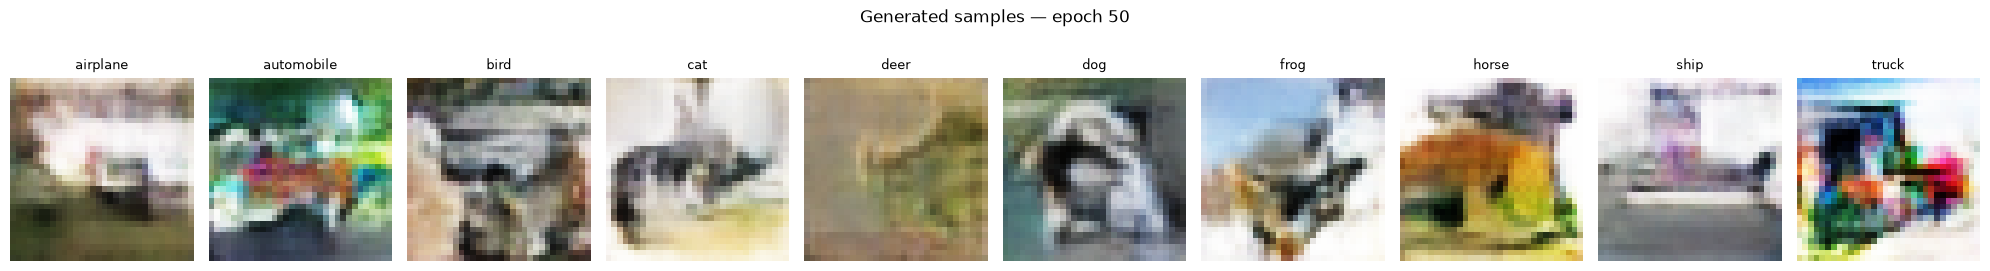

In [ ]:
# CGAN model training

EPOCHS_GAN = 50
fixed_noise = tf.random.normal([10, LATENT_DIM_GAN])
fixed_labels = tf.constant(list(range(10)), dtype=tf.int32)

def show_generated_grid(epoch):
    generated = generator([fixed_noise, tf.reshape(fixed_labels, (-1, 1))], training=False)
    generated = (generated.numpy() * 127.5 + 127.5).astype('uint8')

    fig, axes = plt.subplots(1, 10, figsize=(20, 3))
    for i in range(10):
        axes[i].imshow(generated[i])
        axes[i].set_title(CIFAR10_CLASSES[i], fontsize=9)
        axes[i].axis('off')
    plt.suptitle(f'Generated samples — epoch {epoch}')
    plt.tight_layout()
    plt.show()

gan_history = {'gen_loss': [], 'disc_loss': []}

for epoch in range(1, EPOCHS_GAN + 1):
    epoch_gen_loss, epoch_disc_loss = [], []
    for real_images, real_labels in gan_dataset:
        real_labels = tf.reshape(real_labels, (-1, 1))
        g_loss, d_loss = train_step(real_images, real_labels)
        epoch_gen_loss.append(g_loss.numpy())
        epoch_disc_loss.append(d_loss.numpy())

    gan_history['gen_loss'].append(np.mean(epoch_gen_loss))
    gan_history['disc_loss'].append(np.mean(epoch_disc_loss))

    print(f"Epoch {epoch}/{EPOCHS_GAN} — gen_loss: {gan_history['gen_loss'][-1]:.4f}, "
          f"disc_loss: {gan_history['disc_loss'][-1]:.4f}")

    if epoch % 10 == 0 or epoch == 1:
        show_generated_grid(epoch)

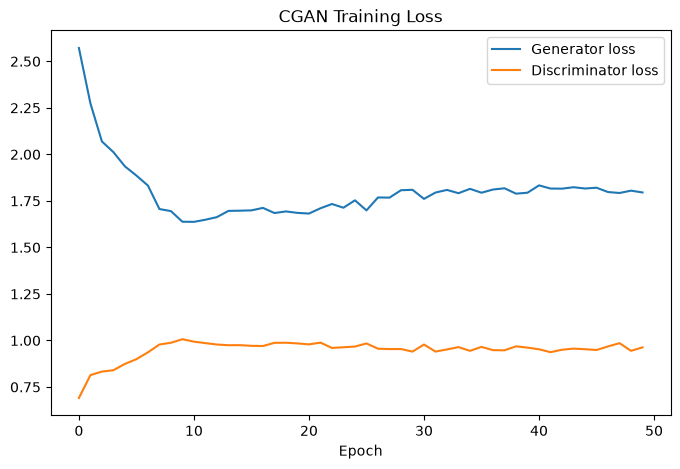

In [ ]:
# CGAN training curve

plt.figure(figsize=(8, 5))
plt.plot(gan_history['gen_loss'], label='Generator loss')
plt.plot(gan_history['disc_loss'], label='Discriminator loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('CGAN Training Loss')
plt.show()

In [ ]:
# Augmented data creation

n_synthetic_per_class = 1000  # ~22% augmentation on top of 45k real images

synthetic_images, synthetic_labels = [], []
for cls in range(NUM_CLASSES):
    noise = tf.random.normal([n_synthetic_per_class, LATENT_DIM_GAN])
    labels = tf.constant([[cls]] * n_synthetic_per_class, dtype=tf.int32)
    imgs = generator([noise, labels], training=False).numpy()
    imgs = imgs * 127.5 + 127.5  # back to 0-255 scale, still float32
    synthetic_images.append(imgs)
    synthetic_labels.append(np.full(n_synthetic_per_class, cls))

synthetic_images = np.concatenate(synthetic_images, axis=0)
synthetic_labels = np.concatenate(synthetic_labels, axis=0)

# Apply the SAME mean/std normalization used for the real classifier pipeline
synthetic_images_norm = (synthetic_images - mean) / std

print(synthetic_images_norm.shape, synthetic_labels.shape)

(10000, 32, 32, 3) (10000,)


In [ ]:
# Combine real + synthetic training data

X_train_augmented = np.concatenate([X_train, synthetic_images_norm], axis=0)
y_train_augmented = np.concatenate([y_train, synthetic_labels], axis=0)

shuffle_aug = np.random.RandomState(SEED).permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_aug]
y_train_augmented = y_train_augmented[shuffle_aug]

print("Augmented train set size:", X_train_augmented.shape)

Augmented train set size: (55000, 32, 32, 3)


In [ ]:
# Shallow CNN model on augmented data

cnn_gan_augmented = build_cnn_simple()

history_cnn_augmented = cnn_gan_augmented.fit(
    X_train_augmented, y_train_augmented,
    validation_data=(X_val, y_val),   # validate on REAL data only
    epochs=40,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
)

# Evaluation using only real data in test set

aug_metrics, aug_cm = evaluate_and_log(
    'CNN_shallow_GAN_augmented', cnn_gan_augmented, X_test, y_test,
    extra_info={'architecture': 'CNN_shallow', 'synthetic_ratio': n_synthetic_per_class * NUM_CLASSES / len(X_train)}
)

Epoch 1/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.4914 - loss: 1.4524 - val_accuracy: 0.5826 - val_loss: 1.1670
Epoch 2/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.6239 - loss: 1.0965 - val_accuracy: 0.6332 - val_loss: 1.0187
Epoch 3/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.6593 - loss: 0.9923 - val_accuracy: 0.6646 - val_loss: 0.9380
Epoch 4/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 80ms/step - accuracy: 0.6822 - loss: 0.9244 - val_accuracy: 0.6836 - val_loss: 0.8991
Epoch 5/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.6985 - loss: 0.8828 - val_accuracy: 0.6672 - val_loss: 0.9342
Epoch 6/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.7085 - loss: 0.8487 - val_accuracy: 0.6882 - val_loss: 0.8849
Epoch 7/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.7212 - loss: 0.8184 - val_accuracy: 0.6960 - val_loss: 0.8596
Epoch 8/40
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.7291 - loss: 0.7966 - 

In [ ]:
# Direct before/after comparison: real-only vs GAN-augmented, same architecture

pd.DataFrame(results_store)[['model_name', 'accuracy', 'macro_f1']].query(
    "model_name in ['CNN_shallow', 'CNN_shallow_GAN_augmented']"
)

,model_name,accuracy,macro_f1
3,CNN_shallow,0.771,0.768328
6,CNN_shallow_GAN_augmented,0.751,0.746624


In [45]:
results_df = pd.DataFrame(results_store)
results_df

,model_name,accuracy,macro_f1,precision_macro,recall_macro,n_params,inference_time_sec,latent_dim,architecture,synthetic_ratio
0,MLP_baseline_raw_pixels,0.5733,0.572900,0.574883,0.5733,3812618,2.806372,NaN,NaN,NaN
1,MLP_on_AE_latent,0.5722,0.569160,0.570180,0.5722,797962,2.698686,128.0,NaN,NaN
2,MLP_on_VAE_latent,0.5631,0.559285,0.561311,0.5631,797962,2.719216,128.0,NaN,NaN
3,CNN_shallow,0.7710,0.768328,0.769513,0.7710,545098,4.596532,NaN,CNN_shallow,NaN
4,CNN_deep_residual,0.8417,0.841436,0.847566,0.8417,593578,20.774675,NaN,CNN_deep_residual,NaN
5,CNN_wide_gap,0.8107,0.807262,0.814207,0.8107,170122,20.899694,NaN,CNN_wide_gap,NaN
6,CNN_shallow_GAN_augmented,0.7510,0.746624,0.752014,0.7510,545098,4.048687,NaN,CNN_shallow,0.222222


In [ ]:
classifier_results = results_df[results_df['model_name'] != 'CGAN'].copy()
gan_result = results_df[results_df['model_name'] == 'CGAN'].copy()

classifier_results = classifier_results.sort_values('accuracy', ascending=False).reset_index(drop=True)
classifier_results[['model_name', 'accuracy', 'macro_f1', 'precision_macro', 'recall_macro', 'n_params', 'inference_time_sec']]

,model_name,accuracy,macro_f1,precision_macro,recall_macro,n_params,inference_time_sec
0,CNN_deep_residual,0.8417,0.841436,0.847566,0.8417,593578,20.774675
1,CNN_wide_gap,0.8107,0.807262,0.814207,0.8107,170122,20.899694
2,CNN_shallow,0.7710,0.768328,0.769513,0.7710,545098,4.596532
3,CNN_shallow_GAN_augmented,0.7510,0.746624,0.752014,0.7510,545098,4.048687
4,MLP_baseline_raw_pixels,0.5733,0.572900,0.574883,0.5733,3812618,2.806372
5,MLP_on_AE_latent,0.5722,0.569160,0.570180,0.5722,797962,2.698686
6,MLP_on_VAE_latent,0.5631,0.559285,0.561311,0.5631,797962,2.719216


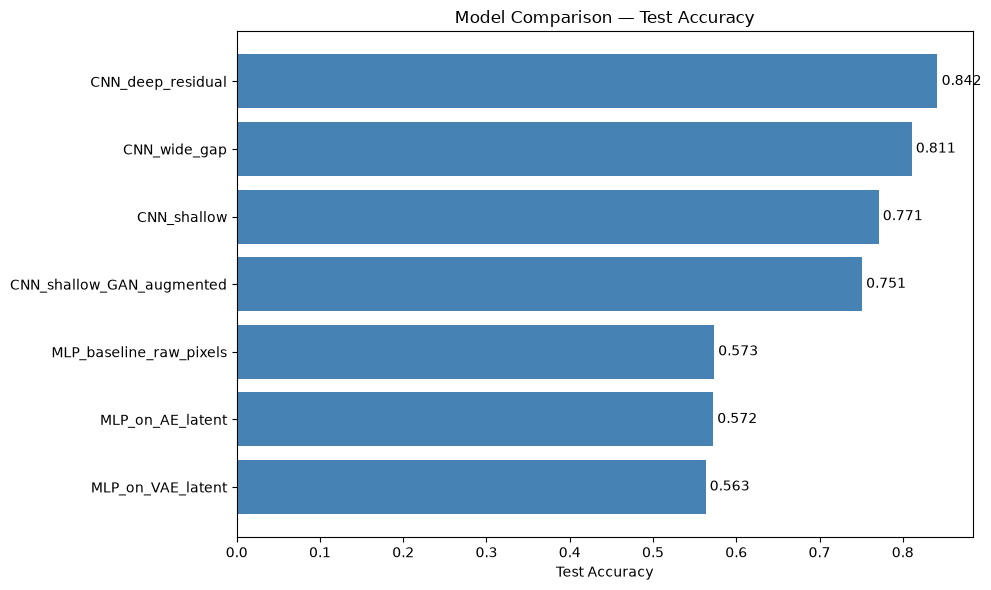

In [ ]:
# Final performance summaries and graphs

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(classifier_results['model_name'], classifier_results['accuracy'], color='steelblue')
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy')
ax.invert_yaxis()

for bar, acc in zip(bars, classifier_results['accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f'{acc:.3f}', va='center')

plt.tight_layout()
plt.show()

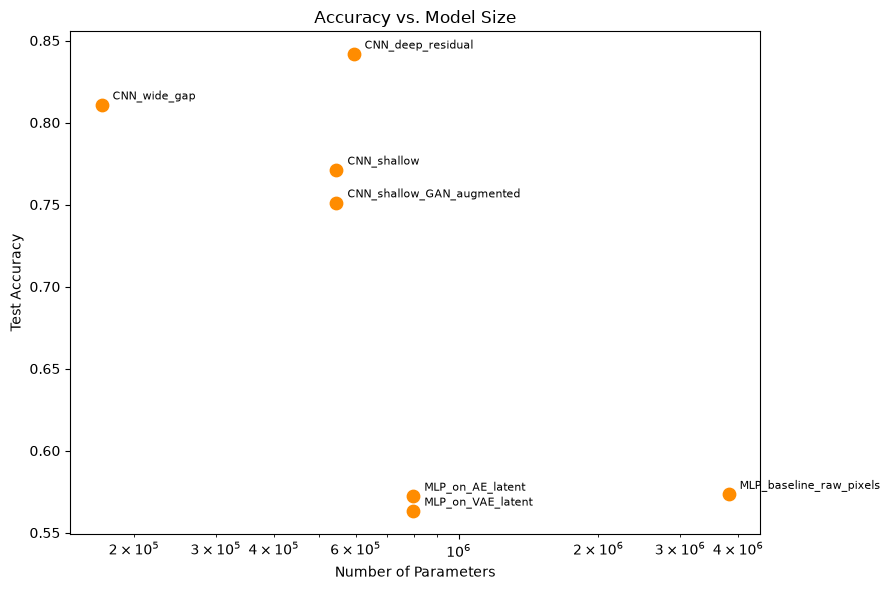

In [48]:
plt.figure(figsize=(9, 6))
plt.scatter(classifier_results['n_params'], classifier_results['accuracy'], s=80, color='darkorange')

for _, row in classifier_results.iterrows():
    plt.annotate(row['model_name'], (row['n_params'], row['accuracy']),
                 textcoords="offset points", xytext=(8, 4), fontsize=8)

plt.xlabel('Number of Parameters')
plt.ylabel('Test Accuracy')
plt.xscale('log')
plt.title('Accuracy vs. Model Size')
plt.tight_layout()
plt.show()

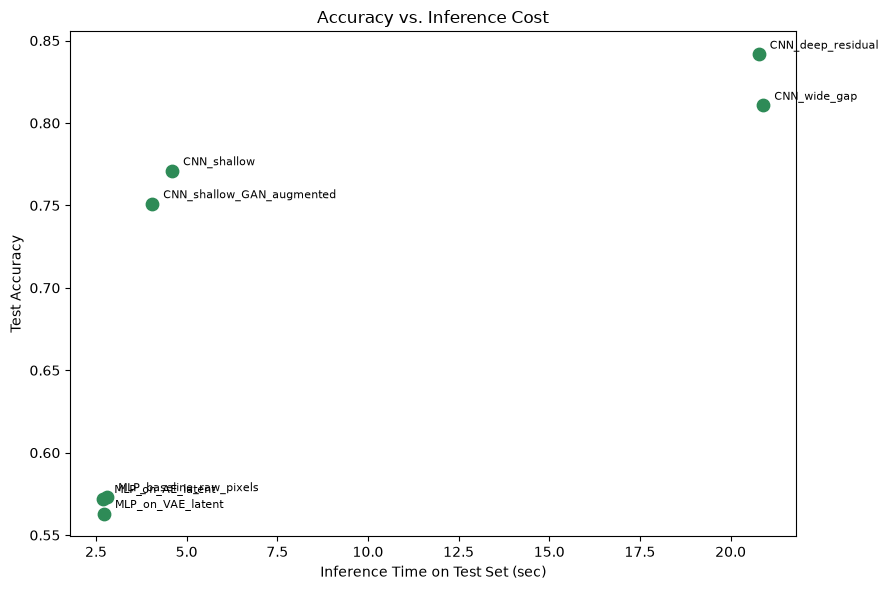

In [49]:
plt.figure(figsize=(9, 6))
plt.scatter(classifier_results['inference_time_sec'], classifier_results['accuracy'], s=80, color='seagreen')

for _, row in classifier_results.iterrows():
    plt.annotate(row['model_name'], (row['inference_time_sec'], row['accuracy']),
                 textcoords="offset points", xytext=(8, 4), fontsize=8)

plt.xlabel('Inference Time on Test Set (sec)')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs. Inference Cost')
plt.tight_layout()
plt.show()

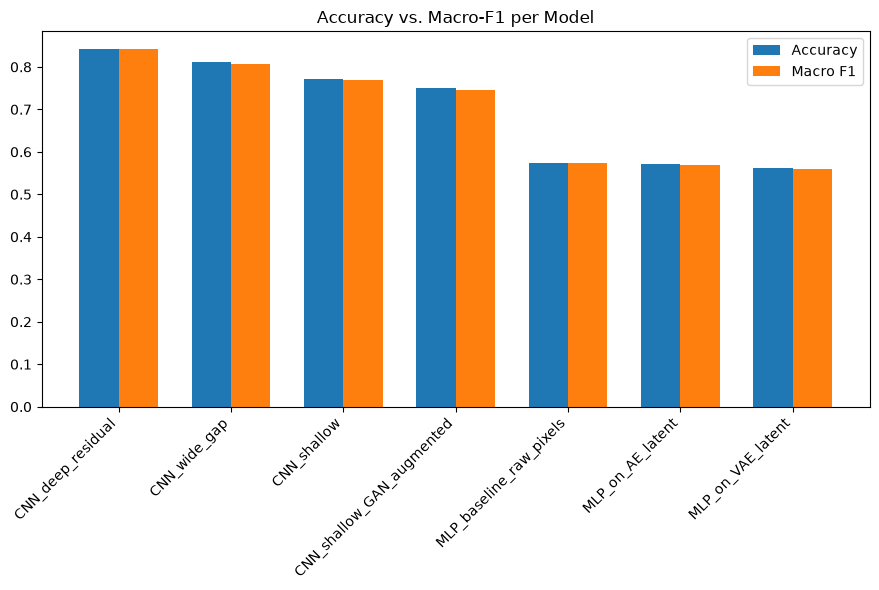

In [50]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(classifier_results))
width = 0.35

ax.bar(x - width/2, classifier_results['accuracy'], width, label='Accuracy')
ax.bar(x + width/2, classifier_results['macro_f1'], width, label='Macro F1')

ax.set_xticks(x)
ax.set_xticklabels(classifier_results['model_name'], rotation=45, ha='right')
ax.set_title('Accuracy vs. Macro-F1 per Model')
ax.legend()
plt.tight_layout()
plt.show()

In [51]:
def show_comparison(names, title):
    subset = classifier_results[classifier_results['model_name'].isin(names)]
    print(f"\n--- {title} ---")
    print(subset[['model_name', 'accuracy', 'macro_f1']].to_string(index=False))

show_comparison(['MLP_baseline_raw_pixels', 'MLP_on_AE_latent', 'MLP_on_VAE_latent'],
                 "Raw pixels vs. compressed latent space (same MLP architecture)")

show_comparison(['CNN_shallow', 'CNN_deep_residual', 'CNN_wide_gap'],
                 "CNN architecture variations")

show_comparison(['CNN_shallow', 'CNN_shallow_GAN_augmented'],
                 "Real-only vs. GAN-augmented training data (same architecture)")


--- Raw pixels vs. compressed latent space (same MLP architecture) ---
             model_name  accuracy  macro_f1
MLP_baseline_raw_pixels    0.5733  0.572900
       MLP_on_AE_latent    0.5722  0.569160
      MLP_on_VAE_latent    0.5631  0.559285

--- CNN architecture variations ---
       model_name  accuracy  macro_f1
CNN_deep_residual    0.8417  0.841436
     CNN_wide_gap    0.8107  0.807262
      CNN_shallow    0.7710  0.768328

--- Real-only vs. GAN-augmented training data (same architecture) ---
               model_name  accuracy  macro_f1
              CNN_shallow     0.771  0.768328
CNN_shallow_GAN_augmented     0.751  0.746624


In [53]:
summary_cols = ['model_name', 'accuracy', 'macro_f1', 'n_params', 'inference_time_sec']
final_summary = classifier_results[summary_cols].copy()
final_summary['rank'] = final_summary['accuracy'].rank(ascending=False).astype(int)
final_summary = final_summary.sort_values('rank')
final_summary

,model_name,accuracy,macro_f1,n_params,inference_time_sec,rank
0,CNN_deep_residual,0.8417,0.841436,593578,20.774675,1
1,CNN_wide_gap,0.8107,0.807262,170122,20.899694,2
2,CNN_shallow,0.7710,0.768328,545098,4.596532,3
3,CNN_shallow_GAN_augmented,0.7510,0.746624,545098,4.048687,4
4,MLP_baseline_raw_pixels,0.5733,0.572900,3812618,2.806372,5
5,MLP_on_AE_latent,0.5722,0.569160,797962,2.698686,6
6,MLP_on_VAE_latent,0.5631,0.559285,797962,2.719216,7


In [ ]:
final_summary.to_csv('results_summary.csv', index=False)
results_df.to_csv('all_results_raw.csv', index=False)
print("Saved results_summary.csv and all_results_raw.csv")

Saved results_summary.csv and all_results_raw.csv
